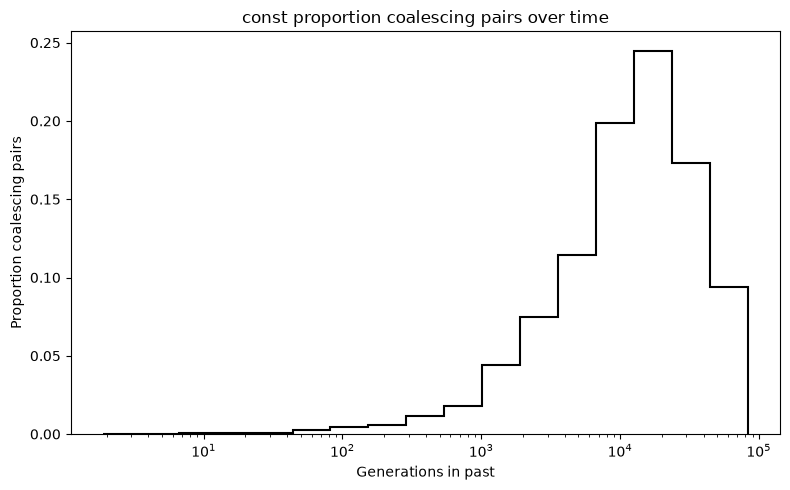

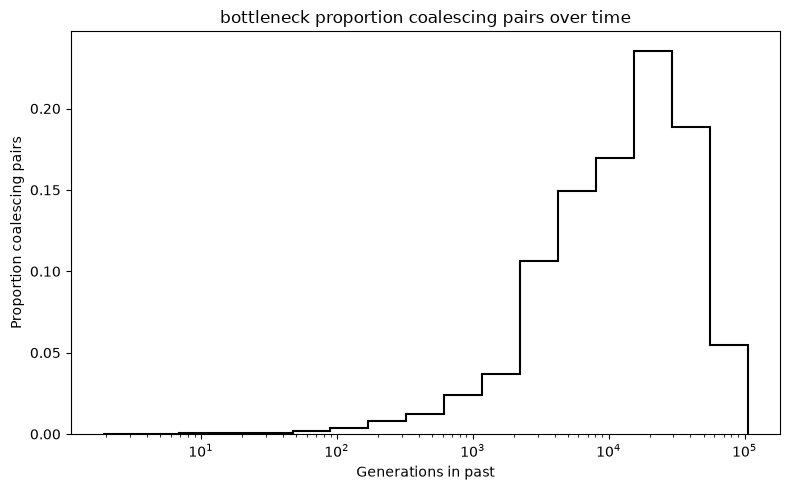

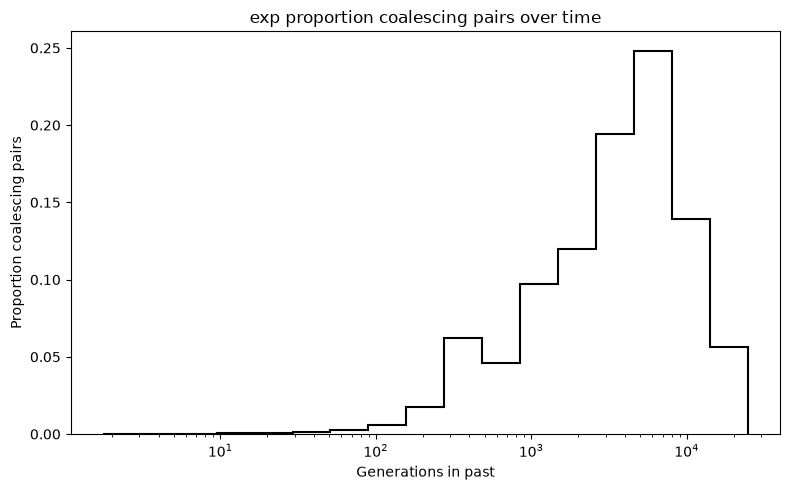

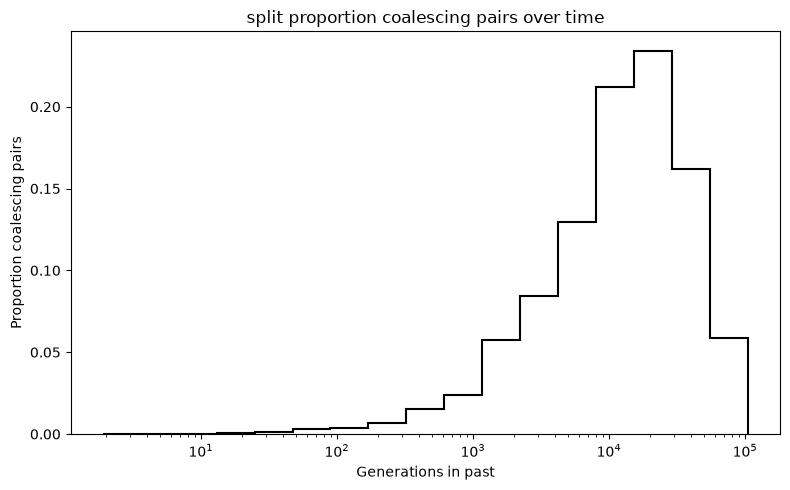

In [39]:

import msprime
import numpy as np
import matplotlib.pyplot as plt


# Creating demographies
#1) Single pop: Constant population size
demoConst = msprime.Demography()
demoConst.add_population (name='popA', initial_size=10000)

#2) Single pop: Bottleneck
demoBottleneck = msprime.Demography()
demoBottleneck.add_population (name='popA', initial_size=5000)
demoBottleneck.add_population_parameters_change (population='popA', time=5, initial_size=10000)


#3) Single pop: Recent exp. growth
demoExp = msprime.Demography()
demoExp.add_population (name='popA', initial_size=10000, growth_rate = np.log(4)/250)
demoExp.add_population_parameters_change (population='popA', time=250, growth_rate = 0)


#4) Two pops: Pop. split
demoSplit= msprime.Demography()
demoSplit.add_population (name='popA', initial_size=5000)
demoSplit.add_population (name='popB', initial_size=5000)
demoSplit.add_population (name='popAB', initial_size=10000)
demoSplit.add_population_split (time=250, derived=["popA", "popB"], ancestral="popAB")

#5) Stepping stone
def isValidDeme(deme, dim):
    """
    Checks whether the given deme is within the boundaries.
    """
    (n, m) = dim
    (i, j) = deme
    isValid = True
    isValid &= ((i >= 0) and (i < n))
    isValid &= ((j >= 0) and (j < m))
    return isValid


# %%
def stepping_stone2d (meta_size, migRate, treeSeq = None):
    """
    sets up a demographic model representing a 2D stepping-stone model
    """
    assert len(meta_size.shape) == 2
    n, m = meta_size.shape

    # just double check
    if ((n == 1) and (m == 1)):
        assert (migRate is None)
    else:
        assert (migRate is not None)
    # fill it in an order where column index j increases fastest until m
    idxToDeme = {}
    # but it starts at 1 because of slim
    currIdx = 1
    for i in range(n):
        for j in range (m):
            idxToDeme[currIdx] = (i,j)
            currIdx += 1

    # the inverse map
    demeToIdx = {}
    for (thisIdx, thisPair) in idxToDeme.items():
        # make sure it matches what we used in SLiM
        assert (thisPair[0]*m + thisPair[1] + 1 == thisIdx)
        demeToIdx[thisPair] = thisIdx

    # we need one bogus population to emulate slim
    if (treeSeq is None):
        demography = msprime.Demography.isolated_model (np.concatenate (([1], meta_size.reshape(n*m))))
        # AS LONG AS THE SECOND INDEX INCREASES FASTER, THE ORDERING OF THE SIZES IS CORRECT
    else:
        # need to initialize from treeSeq, so the populations match
        demography = msprime.Demography.from_tree_sequence(treeSeq)
        for pop in demography.populations:
            # must set their effective population sizes
            if (pop.id < 1):
                # this one is bogus (who knows why SLiM puts it here)
                pop.initial_size = 1
            else:
                # real population
                thisPair = idxToDeme[pop.id]
                pop.initial_size = meta_size[thisPair[0],thisPair[1]]

    # still need to put in migration rates
    migMatrix = demography.migration_matrix
    # iterate over source demes
    # for srcIdx in range(M.shape[0]):
    # this is all due to SLiM, because there is one empty pop in the beginning
    for srcIdx in range(1,migMatrix.shape[0]):
        srcDeme = idxToDeme[srcIdx]
        (srcI, srcJ) = srcDeme
        # don't rename
        # demography.populations[srcIdx].name = f"pop_{srcI}_{srcJ}"
        # print(srcDeme)

        # where can we go from here
        dstDemes = [
            (srcI + 1, srcJ),
            (srcI - 1, srcJ),
            (srcI, srcJ + 1),
            (srcI, srcJ - 1),
        ]
        for dstDeme in dstDemes:
            if isValidDeme(dstDeme, (n,m)):
                # print(f"--> {dstDeme}")
                assert (migRate is not None)
                migMatrix[demeToIdx[srcDeme], demeToIdx[dstDeme]] = migRate
            # else:
                # print(f"-x> {(dstDeme[0] % n, dstDeme[1] % m)}")

    return (demography, idxToDeme, demeToIdx)
meta_size = np.ones((4,4))*500
(demoStep, idxToDeme, demeToIdx) = stepping_stone2d(meta_size,0.005)

deme_list = [demoConst, demoBottleneck, demoExp, demoSplit, demoStep]
demo_names = ["const", "bottleneck", "exp", "split", "step"]
L = 2e6

for i in range(0,4):
    import os
    os.makedirs(f'my-singer-run/example_data/diploid_sim/{demo_names[i]}', exist_ok=True)

    if i == 3:
        samples = {"popA": 50, "popB": 50}
    elif i == 4:
        samples = {f"pop_{num}": 5
                   for num in range(1,17)}
    else:
        samples = {"popA": 100}

    simple_demo = msprime.sim_ancestry(
        demography=deme_list[i],
        samples=samples,
        sequence_length=L,
        recombination_rate=1.25e-8,
        random_seed=121212,
    )
    mutated = msprime.sim_mutations(simple_demo, rate=1.25e-8, random_seed=523802156)
    #rename individuals to include their population index (denoted by DIdx1_DIdx2 for the stepping stone model)
    if i == 4:
        individualNames = []
        indCounter = 0
        for ind in mutated.individuals():
            thisDeme = idxToDeme[mutated.nodes_population[ind.nodes[0]]]
            thisName = f"tsk_D{thisDeme[0]}_D{thisDeme[1]}_{indCounter}"
            individualNames.append (thisName)
            indCounter += 1
    else:
        individualNames = []
        indCounter = 0
        for ind in mutated.individuals():
            thisPop = mutated.nodes_population[ind.nodes[0]]
            thisName = f"tsk_D{thisPop}_{indCounter}"
            individualNames.append (thisName)
            indCounter += 1

    vcf_path = f'my-singer-run/example_data/diploid_sim/{demo_names[i]}/{demo_names[i]}.vcf'
    #Write vcf including newly created individual names
    with open(vcf_path, 'w') as vcf_file:
        mutated.write_vcf(vcf_file, individual_names=individualNames)
        
    #now make graph of probability of pairwise coalescence per time chunk (exponential x axis, matching SINGER output)
    fig, ax = plt.subplots(figsize=(8, 5))
    time_intervals = np.logspace(0, np.log10(mutated.max_time), 20)
    #time_intervals = np.concatenate(([0], time_intervals, [np.inf]))
    #this functions creates a vector of the number of coalescing pairs in each interval
    counts = mutated.pair_coalescence_counts(time_windows=time_intervals, pair_normalise=True)
    #normalize 
    proportions = counts/counts.sum() 
    #ignore 1st and last interval to match singer chart
    ax.stairs(proportions[1:-1], time_intervals[1:-1], color="black", linewidth=1.5)
    ax.set_xscale("log")
    ax.set_xlabel("Generations in past")
    ax.set_ylabel("Proportion coalescing pairs")
    plt.title(f"{demo_names[i]} proportion coalescing pairs over time")
    plt.tight_layout()
    plt.show()


In [38]:
#Now extract the first SINGER outputted ARG as a tree sequence
import tszip
import tskit
import msprime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

for i in range(1,5):
    ts = tszip.decompress(f"my-singer-run/example_data/results/bottleneck/trees/bottleneck.{i}.tsz")
    #tskit.validate_provenance(ts)
    fig, ax = plt.subplots(figsize=(8, 5))
    time_intervals = np.logspace(0, np.log10(ts.max_time), 20)
    time_intervals = np.concatenate(([0], time_intervals, [np.inf]))

    
    #this functions creates a vector of the number of coalescing pairs in each interval
    counts = ts.pair_coalescence_counts(time_windows=time_intervals, pair_normalise=True)
    #normalize 
    proportions = counts/counts.sum() 
    #ignore 1st and last interval to match singer chart
    ax.stairs(proportions[1:-1], time_intervals[1:-1], color="black", linewidth=1.5)
    ax.set_xscale("log")
    ax.set_xlabel("Generations in past")
    ax.set_ylabel("Proportion coalescing pairs")
    plt.title(f"SINGER reconstruction const proportion coalescing pairs over time, Pair Normalize (True)")
    plt.tight_layout()
    plt.show()


    #now make heatmap of coalescent rates across genome and time from present
    time_intervals = np.logspace(0, np.log10(ts.max_time), 20)
    time_intervals = np.concatenate(([0], time_intervals, [np.inf]))
    L = ts.sequence_length
    genome_intervals = np.linspace(0, L, 21)
    ts = tszip.decompress(f"my-singer-run/example_data/results/const/trees/const.{i}.tsz")
    rates = ts.pair_coalescence_rates(time_windows=time_intervals, windows=genome_intervals)
    
    ax = sns.heatmap(rates.T, vmin=0, vmax=np.max(rates[np.isfinite(rates)]), cbar_kws={'label': 'Coalescence rate'})
    ax.set_xticks(np.arange(len(genome_intervals) - 0.5), genome_intervals/1e6, rotation=90)
    ax.set_yticks(np.arange(len(time_intervals) - 0.5), [f"{t:.2f}" for t in time_intervals])
    ax.invert_yaxis()
    ax.set_xlabel("Genome position")
    ax.set_ylabel("Time");
   
    


FileNotFoundError: [Errno 2] No such file or directory: 'my-singer-run/example_data/results/bottleneck/trees/bottleneck.1.tsz'

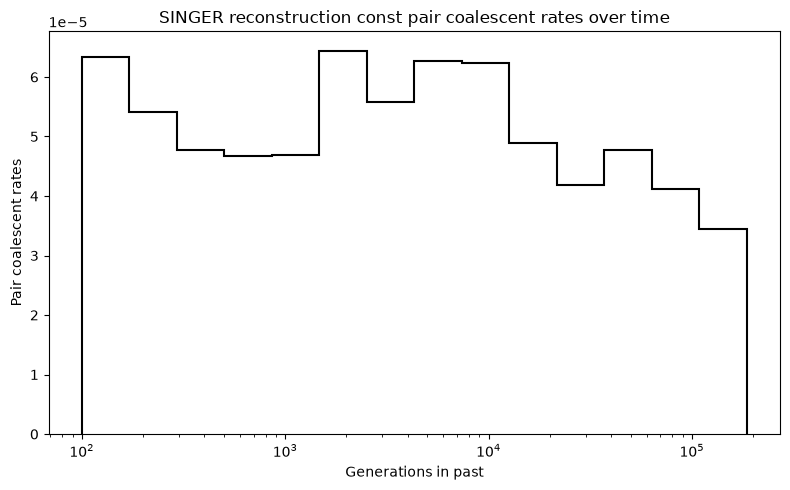

Individual ID 0: None
Individual ID 0: 0
Individual ID 1: None
Individual ID 1: 1
Individual ID 2: None
Individual ID 2: 2
Individual ID 3: None
Individual ID 3: 3
Individual ID 4: None
Individual ID 4: 4
Individual ID 5: None
Individual ID 5: 5
Individual ID 6: None
Individual ID 6: 6
Individual ID 7: None
Individual ID 7: 7
Individual ID 8: None
Individual ID 8: 8
Individual ID 9: None
Individual ID 9: 9
Individual ID 10: None
Individual ID 10: 10
Individual ID 11: None
Individual ID 11: 11
Individual ID 12: None
Individual ID 12: 12
Individual ID 13: None
Individual ID 13: 13
Individual ID 14: None
Individual ID 14: 14
Individual ID 15: None
Individual ID 15: 15
Individual ID 16: None
Individual ID 16: 16
Individual ID 17: None
Individual ID 17: 17
Individual ID 18: None
Individual ID 18: 18
Individual ID 19: None
Individual ID 19: 19
Individual ID 20: None
Individual ID 20: 20
Individual ID 21: None
Individual ID 21: 21
Individual ID 22: None
Individual ID 22: 22
Individual ID 23: 

In [34]:
 #now make heatmap of coalescent rates across genome and time from present
if True:
    time_intervals = np.geomspace(100, ts.max_time, 15)
    time_intervals = np.concatenate(([0], time_intervals, [np.inf]))
    L = ts.sequence_length
    genome_intervals = np.linspace(0, L, 21)
    ts = tszip.decompress(f"my-singer-run/example_data/results/const/trees/const.{i}.tsz")
    rates = ts.pair_coalescence_rates(time_windows=time_intervals)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.stairs(rates[1:-1], time_intervals[1:-1], color="black", linewidth=1.5)
    ax.set_xscale("log")
    ax.set_xlabel("Generations in past")
    ax.set_ylabel("Pair coalescent rates")
    plt.title(f"SINGER reconstruction const pair coalescent rates over time")
    plt.tight_layout()
    plt.show()

    for individual in ts.individuals():
    # If using metadata
        name = individual.metadata.get("name") if individual.metadata else "Unnamed"
        print(f"Individual ID {individual.id}: {name}")
    
    # If the name is saved directly as an id/identifier
        print(f"Individual ID {individual.id}: {individual.id}")
        
    
    # ax = sns.heatmap(rates.T, vmin=0, vmax=np.max(rates[np.isfinite(rates)]), cbar_kws={'label': 'Coalescence rate'})
    # ax.set_xticks(np.arange(len(genome_intervals) - 0.5), genome_intervals/1e6, rotation=90)
    # ax.set_yticks(np.arange(len(time_intervals) - 0.5), [f"{t:.2f}" for t in time_intervals])
    # ax.invert_yaxis()
    # ax.set_xlabel("Genome position")
    # ax.set_ylabel("Time");
   
    


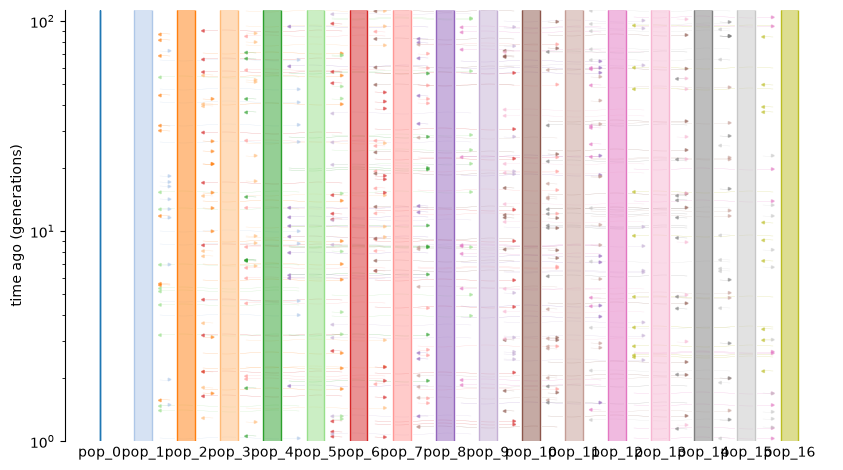

In [31]:
vcf_path = f'my-singer-run/example_data/diploid_sim/const/const.vcf.gz'
ts_

In [30]:
pip install demesdraw

Note: you may need to restart the kernel to use updated packages.


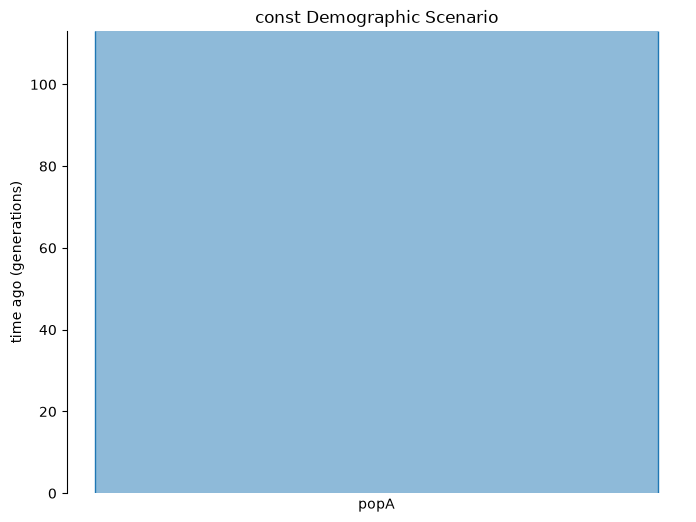

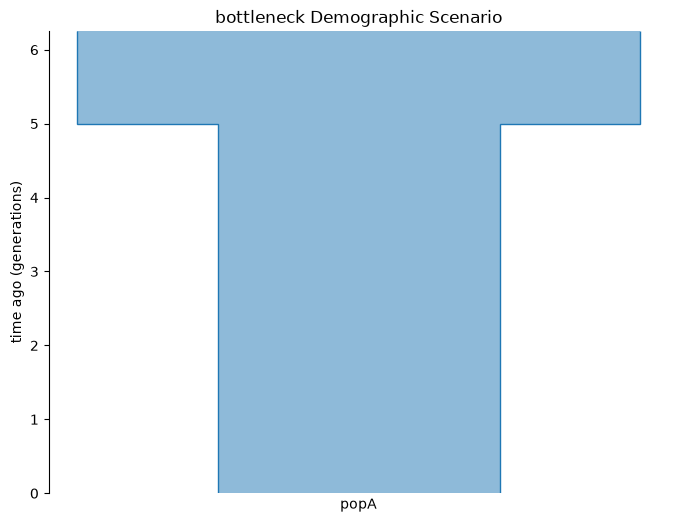

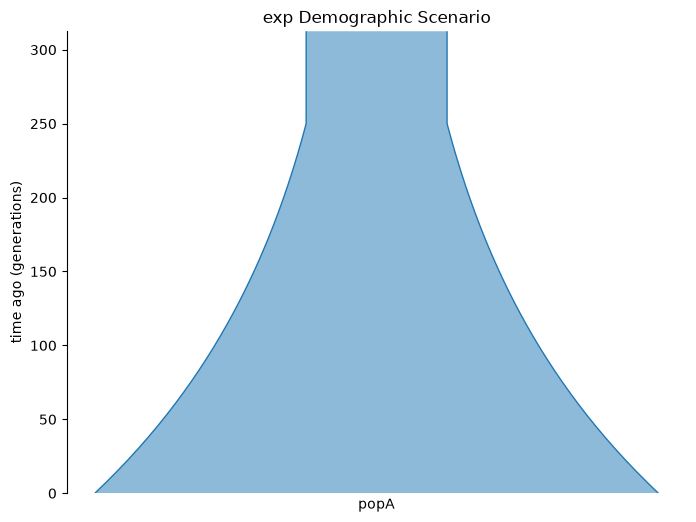

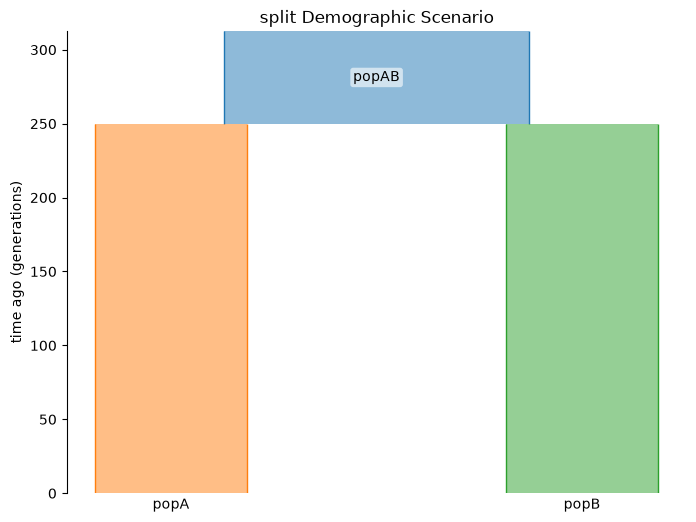

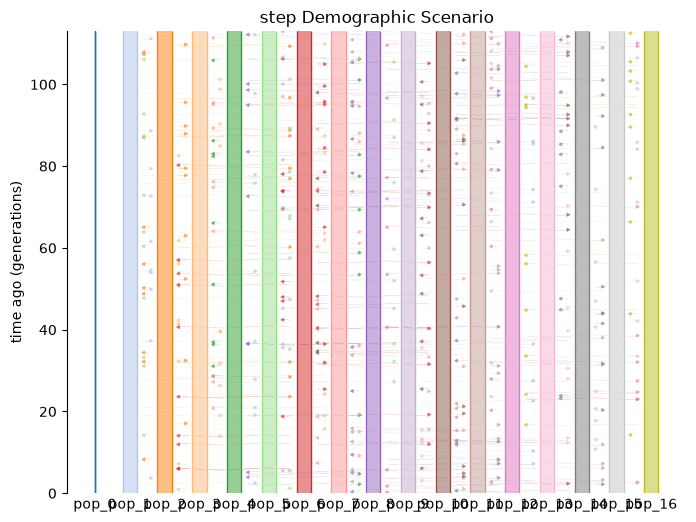

In [5]:
import msprime
import numpy as np
import matplotlib.pyplot as plt
import demesdraw

# Creating demographies
#1) Single pop: Constant population size
demoConst = msprime.Demography()
demoConst.add_population (name='popA', initial_size=10000)

#2) Single pop: Bottleneck
demoBottleneck = msprime.Demography()
demoBottleneck.add_population (name='popA', initial_size=5000)
demoBottleneck.add_population_parameters_change (population='popA', time=5, initial_size=10000)


#3) Single pop: Recent exp. growth
demoExp = msprime.Demography()
demoExp.add_population (name='popA', initial_size=10000, growth_rate = np.log(4)/250)
demoExp.add_population_parameters_change (population='popA', time=250, growth_rate = 0)


#4) Two pops: Pop. split
demoSplit= msprime.Demography()
demoSplit.add_population (name='popA', initial_size=5000)
demoSplit.add_population (name='popB', initial_size=5000)
demoSplit.add_population (name='popAB', initial_size=10000)
demoSplit.add_population_split (time=250, derived=["popA", "popB"], ancestral="popAB")

#5) Stepping stone
def isValidDeme(deme, dim):
    """
    Checks whether the given deme is within the boundaries.
    """
    (n, m) = dim
    (i, j) = deme
    isValid = True
    isValid &= ((i >= 0) and (i < n))
    isValid &= ((j >= 0) and (j < m))
    return isValid


# %%
def stepping_stone2d (meta_size, migRate, treeSeq = None):
    """
    sets up a demographic model representing a 2D stepping-stone model
    """
    assert len(meta_size.shape) == 2
    n, m = meta_size.shape

    # just double check
    if ((n == 1) and (m == 1)):
        assert (migRate is None)
    else:
        assert (migRate is not None)
    # fill it in an order where column index j increases fastest until m
    idxToDeme = {}
    # but it starts at 1 because of slim
    currIdx = 1
    for i in range(n):
        for j in range (m):
            idxToDeme[currIdx] = (i,j)
            currIdx += 1

    # the inverse map
    demeToIdx = {}
    for (thisIdx, thisPair) in idxToDeme.items():
        # make sure it matches what we used in SLiM
        assert (thisPair[0]*m + thisPair[1] + 1 == thisIdx)
        demeToIdx[thisPair] = thisIdx

    # we need one bogus population to emulate slim
    if (treeSeq is None):
        demography = msprime.Demography.isolated_model (np.concatenate (([1], meta_size.reshape(n*m))))
        # AS LONG AS THE SECOND INDEX INCREASES FASTER, THE ORDERING OF THE SIZES IS CORRECT
    else:
        # need to initialize from treeSeq, so the populations match
        demography = msprime.Demography.from_tree_sequence(treeSeq)
        for pop in demography.populations:
            # must set their effective population sizes
            if (pop.id < 1):
                # this one is bogus (who knows why SLiM puts it here)
                pop.initial_size = 1
            else:
                # real population
                thisPair = idxToDeme[pop.id]
                pop.initial_size = meta_size[thisPair[0],thisPair[1]]

    # still need to put in migration rates
    migMatrix = demography.migration_matrix
    # iterate over source demes
    # for srcIdx in range(M.shape[0]):
    # this is all due to SLiM, because there is one empty pop in the beginning
    for srcIdx in range(1,migMatrix.shape[0]):
        srcDeme = idxToDeme[srcIdx]
        (srcI, srcJ) = srcDeme
        # don't rename
        # demography.populations[srcIdx].name = f"pop_{srcI}_{srcJ}"
        # print(srcDeme)

        # where can we go from here
        dstDemes = [
            (srcI + 1, srcJ),
            (srcI - 1, srcJ),
            (srcI, srcJ + 1),
            (srcI, srcJ - 1),
        ]
        for dstDeme in dstDemes:
            if isValidDeme(dstDeme, (n,m)):
                # print(f"--> {dstDeme}")
                assert (migRate is not None)
                migMatrix[demeToIdx[srcDeme], demeToIdx[dstDeme]] = migRate
            # else:
                # print(f"-x> {(dstDeme[0] % n, dstDeme[1] % m)}")

    return (demography, idxToDeme, demeToIdx)
meta_size = np.ones((4,4))*500
(demoStep, idxToDeme, demeToIdx) = stepping_stone2d(meta_size,0.005)

deme_list = [demoConst, demoBottleneck, demoExp, demoSplit, demoStep]
demo_names = ["const", "bottleneck", "exp", "split", "step"]
L = 2e6

for i in range(0,5):
    graph = deme_list[i].to_demes()

    # 3. Plot the demographic model using demesdraw
    # You can use demesdraw.tubes() or demesdraw.size_history()
    fig, ax = plt.subplots(figsize=(8, 6))
    demesdraw.tubes(graph, ax=ax)
    plt.title(f'{demo_names[i]} Demographic Scenario')
    plt.show()